# Handling Imbalanced Data — Weighted Loss & Weighted Sampling

Real-world datasets are often **imbalanced** (some classes have far more samples than others). This notebook shows two main strategies:
1. **Weighted Loss** — penalize mistakes on minority classes more
2. **WeightedRandomSampler** — oversample minority classes during training

In [1]:
import torch, random
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Create an Artificially Imbalanced Dataset

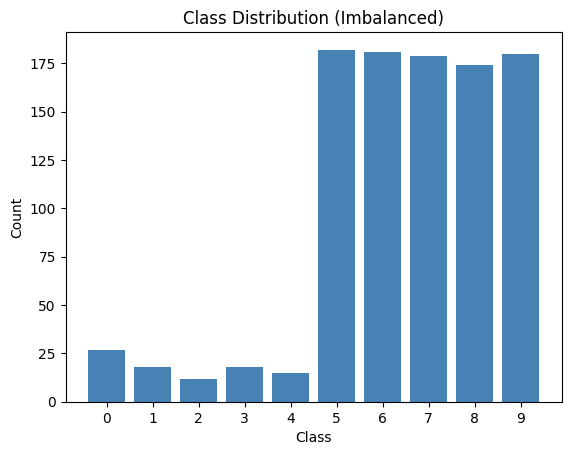

Class counts: {0: 27, 1: 18, 2: 12, 3: 18, 4: 15, 5: 182, 6: 181, 7: 179, 8: 174, 9: 180}


In [2]:
digits = load_digits()
X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

# Keep only 10% of samples from classes 0-4 (create imbalance)
balanced_idx  = np.where(y >= 5)[0]
minority_idx  = np.where(y <  5)[0]
minority_idx  = np.random.choice(minority_idx, size=int(len(minority_idx) * 0.1), replace=False)
idx           = np.concatenate([balanced_idx, minority_idx])

X_imb, y_imb = X[idx], y[idx]

# Show class distribution
unique, counts = np.unique(y_imb, return_counts=True)
plt.bar([str(c) for c in unique], counts, color="steelblue")
plt.title("Class Distribution (Imbalanced)"); plt.xlabel("Class"); plt.ylabel("Count")
plt.show()
print("Class counts:", dict(zip(unique.tolist(), counts.tolist())))

## 2. Train/Test Split & Tensors

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=seed, stratify=y_imb
)
X_tr_t = torch.tensor(X_tr); y_tr_t = torch.tensor(y_tr)
X_te_t = torch.tensor(X_te); y_te_t = torch.tensor(y_te)

train_ds = TensorDataset(X_tr_t, y_tr_t)
test_ds  = TensorDataset(X_te_t, y_te_t)

## 3. Strategy 1 — Weighted Cross-Entropy Loss
Give the model a higher penalty for misclassifying minority (underrepresented) classes.

In [4]:
num_classes = 10
class_counts = np.bincount(y_tr, minlength=num_classes)
class_weights = 1.0 / (class_counts + 1e-6)         # inverse frequency
class_weights = class_weights / class_weights.sum()  # normalize

w_tensor  = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion_weighted = nn.CrossEntropyLoss(weight=w_tensor)

print("Class weights:", np.round(class_weights, 4))

Class weights: [0.1118 0.1757 0.246  0.1757 0.205  0.017  0.017  0.0172 0.0177 0.0171]


## 4. Strategy 2 — WeightedRandomSampler
Oversample minority classes so each mini-batch has a more balanced distribution.

In [5]:
# Assign a weight to each training sample based on its class
sample_weights = torch.tensor(
    [class_weights[label] for label in y_tr], dtype=torch.float32
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True     # allows oversampling
)

# Use sampler instead of shuffle=True
train_loader_sampler = DataLoader(train_ds, batch_size=64, sampler=sampler)
test_loader          = DataLoader(test_ds,  batch_size=64, shuffle=False)

print("Sampler ready — minority classes will appear more frequently in each batch")

Sampler ready — minority classes will appear more frequently in each batch


## 5. Model Definition

In [6]:
class MLPModel(nn.Module):
    def __init__(self, in_dim=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,  64),  nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)

## 6. Compare: Baseline vs Weighted Loss vs Weighted Sampler

In [7]:
def run_experiment(name, loader, criterion, epochs=15):
    m = MLPModel().to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    for ep in range(epochs):
        m.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward(); opt.step()

    # Evaluate
    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds.extend(m(xb.to(device)).argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    from sklearn.metrics import accuracy_score
    acc = accuracy_score(trues, preds)
    print(f"\n=== {name} === Overall Acc: {acc:.4f}")
    print(classification_report(trues, preds, zero_division=0))
    return acc

# Run with standard loader + standard loss
train_loader_std = DataLoader(train_ds, batch_size=64, shuffle=True)
run_experiment("Baseline (no fix)",          train_loader_std,     nn.CrossEntropyLoss())
run_experiment("Weighted Loss",              train_loader_std,     criterion_weighted)
run_experiment("Weighted Sampler",           train_loader_sampler, nn.CrossEntropyLoss())


=== Baseline (no fix) === Overall Acc: 0.9040
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         3
           5       0.94      0.92      0.93        37
           6       0.92      1.00      0.96        36
           7       0.95      1.00      0.97        36
           8       0.92      0.94      0.93        35
           9       0.81      0.97      0.89        36

    accuracy                           0.90       198
   macro avg       0.55      0.58      0.57       198
weighted avg       0.85      0.90      0.88       198


=== Weighted Loss === Overall Acc: 0.9293
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.50      0.75      0.6

0.9141414141414141

## 7. Key Takeaways
| Strategy | How it works | Best when |
|---|---|---|
| **Weighted Loss** | Larger penalty for minority class errors | You can't change the data loading pipeline |
| **Weighted Sampler** | Oversample minority at batch level | You have control over DataLoader |
| **Both combined** | Use both together | Extreme imbalance |